# 1
# a

In [1]:
from cornac.datasets import movielens
import pandas as pd


ratings = movielens.load_feedback(variant='100K')


df = pd.DataFrame(ratings, columns=['user_id', 'item_id', 'rating'])
print(20*"#")
print("Normal dataset with rating")
print(df.head())

implicit_feedback = df[df['rating'] >= 3][['user_id', 'item_id']].copy()

print(20*"#")
print("Implicit feedback dataset")
print(implicit_feedback.head())
print(f"Shape: {implicit_feedback.shape}")

####################
Normal dataset with rating
  user_id item_id  rating
0     196     242     3.0
1     186     302     3.0
2      22     377     1.0
3     244      51     2.0
4     166     346     1.0
####################
Implicit feedback dataset
  user_id item_id
0     196     242
1     186     302
5     298     474
7     253     465
8     305     451
Shape: (82520, 2)


# b
**Discuss the implications of treating missing interactions as unknown or negative feed-
back, and explain why implicit recommendation settings are fundamentally different from
explicit rating prediction**


If we treat missing interactions as unknown or as negative feedback this makes a huge difference. 

In the first case if a user doesn't interact with a movie we are optimistic and think the user probably just hasn't seen it yet. 
If we treat that as negative feedback we are much more negative, we think he actively didn't want this option. 
Both can be wrong or right but we don't know precisely. 

Imagine a new user (cold start) in theory every item is a negative item because the user has no interactions with them, in this case in 
theory the system would actively not recommend every item. On the other hand if we treat it as "we don't know" then all options would be 
equally viable. 

The advantage of explicit ratings is that we know for sure what the user has thought about something (either positive or negative). But we still don't know 
if films the user hasn't seen or interacted with are because the user didn't like them or if he hasn't seen it.  

Implicit recommendation settings are also different in another way because they focus on what users actually did (interactions) 
rather than what they said (ratings). This means the interpretation of missing data is more ambiguous, but also more honest—
it reflects real behavior rather than potentially biased ratings (because users probably only rate very good and very bad movies).

# c

In [2]:
from cornac.datasets import movielens
from cornac.models import BPR
from cornac.eval_methods import RatioSplit
from cornac.metrics import Recall, Precision, NDCG
import pandas as pd
import numpy as np 


ratings = movielens.load_feedback(variant='100K')
df = pd.DataFrame(ratings, columns=['user_id', 'item_id', 'rating'])


implicit_feedback = df[df['rating'] >= 3][['user_id', 'item_id']].copy()
implicit_feedback['rating'] = 1.0

eval_method = RatioSplit(implicit_feedback.values, test_size=0.2)


bpr = BPR(
    k=10, # dimensions
    max_iter=100, 
    learning_rate=0.01,
    lambda_reg=0.001 # regularisation 
)


eval_method.evaluate(
    bpr,
    metrics=[Recall(k=10), Precision(k=10), NDCG(k=10)],
    user_based=True
)


print("\nUser 0 Embedding:", bpr.u_factors[0])
print("Item 0 Embedding:", bpr.i_factors[0])
print("Shape u_factors (Users):", bpr.u_factors.shape)
print("Shape i_factors (Items):", bpr.i_factors.shape)


User 0 Embedding: [ 1.0330534   0.04899414  1.0234371   0.37373212 -0.4755269  -1.7380906
 -0.01411714 -1.2019235  -0.8432956   0.8129097 ]
Item 0 Embedding: [ 0.7209176  -0.287466   -0.19492269  0.17649968 -0.71227175 -0.16629022
  0.2522358  -0.13765524  0.6421906   1.0299466 ]
Shape u_factors (Users): (943, 10)
Shape i_factors (Items): (1548, 10)


## explanation 

The users as well as the items are represented as a vector. Because we selected **k=10** we have 10 dimensions. This means each user and each item consists of a 
array with 10 elements (float). 
Every item in the array is one latent factor, one factor could be "likes action" or "has indiana jones in it", but we dont really know what the factors are they are learned 
by the BPR and we don't know what it has learned. 

During the training the model tries to optimize the pairwise ranking. For that the model tries to achieve $score(user, element_{positive}) > score(user, element_{negative})$.
The score for one item is calculated by taking the dot product $score = user*element$. 
In the training the model compares positive items with random negatives and calculate the score. With that it can calculate a loss and use gradient descent to calculate new gradients (weights). This is done multiple times as specified in the hyperparameters. 

# d) 

In [3]:
from cornac.datasets import movielens
from cornac.models import BPR
from cornac.eval_methods import RatioSplit
from cornac.metrics import Recall, Precision, NDCG
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


ratings = movielens.load_feedback(variant='100K')
df = pd.DataFrame(ratings, columns=['user_id', 'item_id', 'rating'])
implicit_feedback = df[df['rating'] >= 3][['user_id', 'item_id']].copy()
implicit_feedback['rating'] = 1.0

hyperparams = {
    'k': [5,  10, 20, 50],
    'learning_rate': [0.001, 0.01, 0.05],
    'lambda_reg': [0.0001, 0.001, 0.01],
    'max_iter': [50, 100, 200]
}

results = []
total_runs = len(hyperparams['k']) * len(hyperparams['learning_rate']) * len(hyperparams['lambda_reg']) * len(hyperparams['max_iter'])
run_count = 0

for k in hyperparams['k']:
    for lr in hyperparams['learning_rate']:
        for reg in hyperparams['lambda_reg']:
            for max_iter in hyperparams['max_iter']:
                run_count += 1
                print(f"[{run_count}/{total_runs}] k={k}, lr={lr}, reg={reg}, max_iter={max_iter}", end=" ... ")
                
                eval_method = RatioSplit(implicit_feedback.values, test_size=0.2, seed=123, verbose=False)
                
                bpr = BPR(
                    k=k,
                    learning_rate=lr,
                    lambda_reg=reg,
                    max_iter=max_iter,
                    verbose=False
                )
                
                result, _ = eval_method.evaluate(
                    bpr,
                    metrics=[Recall(k=10), Precision(k=10), NDCG(k=10)],
                    user_based=True
                )
                
                avg_results = result.metric_avg_results
                
                result_dict = {
                    'k': k,
                    'lr': lr,
                    'lambda_reg': reg,
                    'max_iter': max_iter,
                    'recall@10': avg_results.get('Recall@10', None),
                    'precision@10': avg_results.get('Precision@10', None),
                    'ndcg@10': avg_results.get('NDCG@10', None),
                }
                results.append(result_dict)
                print("")

results_df = pd.DataFrame(results)
results_df.to_csv('bpr_grid_search_results.csv', index=False)

print("\n" + "="*80)
print("GRID SEARCH RESULTS:")
print(results_df)

print("\n" + "="*80)
print("TOP 10 MODELS (nach NDCG@10):")
print(results_df.nlargest(10, 'ndcg@10')[['k', 'lr', 'lambda_reg', 'max_iter', 'ndcg@10', 'recall@10', 'precision@10']])

print("\n" + "="*80)
print("PARAMETER IMPACT ANALYSIS:")
print("\nEffect von k:")
print(results_df.groupby('k')[['recall@10', 'precision@10', 'ndcg@10']].mean().round(4))
print("\nEffect von learning_rate:")
print(results_df.groupby('lr')[['recall@10', 'precision@10', 'ndcg@10']].mean().round(4))
print("\nEffect von lambda_reg:")
print(results_df.groupby('lambda_reg')[['recall@10', 'precision@10', 'ndcg@10']].mean().round(4))
print("\nEffect von max_iter:")
print(results_df.groupby('max_iter')[['recall@10', 'precision@10', 'ndcg@10']].mean().round(4))

[1/108] k=5, lr=0.001, reg=0.0001, max_iter=50 ... 
[2/108] k=5, lr=0.001, reg=0.0001, max_iter=100 ... 
[3/108] k=5, lr=0.001, reg=0.0001, max_iter=200 ... 
[4/108] k=5, lr=0.001, reg=0.001, max_iter=50 ... 
[5/108] k=5, lr=0.001, reg=0.001, max_iter=100 ... 
[6/108] k=5, lr=0.001, reg=0.001, max_iter=200 ... 
[7/108] k=5, lr=0.001, reg=0.01, max_iter=50 ... 
[8/108] k=5, lr=0.001, reg=0.01, max_iter=100 ... 
[9/108] k=5, lr=0.001, reg=0.01, max_iter=200 ... 
[10/108] k=5, lr=0.01, reg=0.0001, max_iter=50 ... 
[11/108] k=5, lr=0.01, reg=0.0001, max_iter=100 ... 
[12/108] k=5, lr=0.01, reg=0.0001, max_iter=200 ... 
[13/108] k=5, lr=0.01, reg=0.001, max_iter=50 ... 
[14/108] k=5, lr=0.01, reg=0.001, max_iter=100 ... 
[15/108] k=5, lr=0.01, reg=0.001, max_iter=200 ... 
[16/108] k=5, lr=0.01, reg=0.01, max_iter=50 ... 
[17/108] k=5, lr=0.01, reg=0.01, max_iter=100 ... 
[18/108] k=5, lr=0.01, reg=0.01, max_iter=200 ... 
[19/108] k=5, lr=0.05, reg=0.0001, max_iter=50 ... 
[20/108] k=5, lr=0

Rows: 108


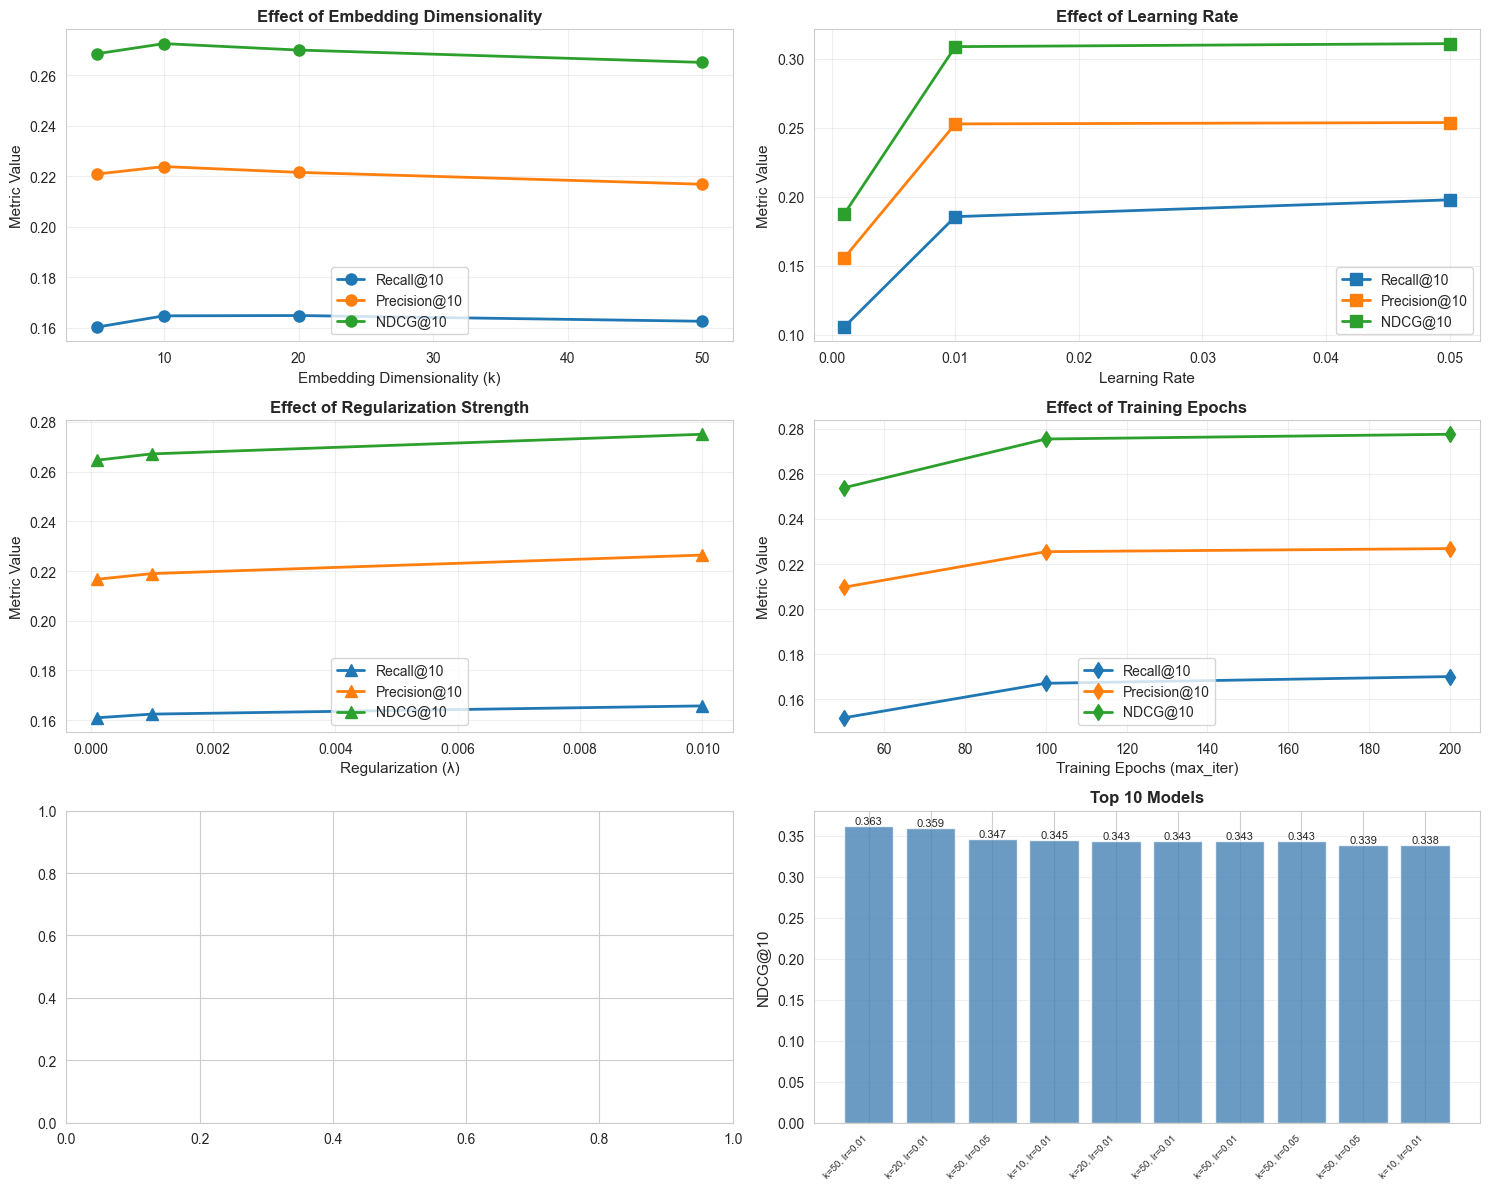


BEST MODEL

k=50, lr=0.01, λ=0.01, max_iter=200
NDCG@10: 0.3625
Recall@10: 0.2230
Precision@10: 0.2936

PARAMETER IMPACT (sorted by importance)
learning_rate       : 0.070677
max_iter            : 0.013137
lambda_reg          : 0.005453
k                   : 0.003106


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


results_df = pd.read_csv('bpr_grid_search_results.csv')


results_df = results_df.dropna()
print(f"Rows: {len(results_df)}")


sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))


ax = axes[0, 0]
k_data = results_df.groupby('k')[['recall@10', 'precision@10', 'ndcg@10']].mean()
k_data.plot(ax=ax, marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Embedding Dimensionality (k)', fontsize=11)
ax.set_ylabel('Metric Value', fontsize=11)
ax.set_title('Effect of Embedding Dimensionality', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(['Recall@10', 'Precision@10', 'NDCG@10'])


ax = axes[0, 1]
lr_data = results_df.groupby('lr')[['recall@10', 'precision@10', 'ndcg@10']].mean()
lr_data.plot(ax=ax, marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Learning Rate', fontsize=11)
ax.set_ylabel('Metric Value', fontsize=11)
ax.set_title('Effect of Learning Rate', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(['Recall@10', 'Precision@10', 'NDCG@10'])


ax = axes[1, 0]
reg_data = results_df.groupby('lambda_reg')[['recall@10', 'precision@10', 'ndcg@10']].mean()
reg_data.plot(ax=ax, marker='^', linewidth=2, markersize=8)
ax.set_xlabel('Regularization (λ)', fontsize=11)
ax.set_ylabel('Metric Value', fontsize=11)
ax.set_title('Effect of Regularization Strength', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(['Recall@10', 'Precision@10', 'NDCG@10'])


ax = axes[1, 1]
iter_data = results_df.groupby('max_iter')[['recall@10', 'precision@10', 'ndcg@10']].mean()
iter_data.plot(ax=ax, marker='d', linewidth=2, markersize=8)
ax.set_xlabel('Training Epochs (max_iter)', fontsize=11)
ax.set_ylabel('Metric Value', fontsize=11)
ax.set_title('Effect of Training Epochs', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(['Recall@10', 'Precision@10', 'NDCG@10'])





ax = axes[2, 1]
top_10 = results_df.nlargest(10, 'ndcg@10').reset_index(drop=True)
top_10_labels = [f"k={int(row['k'])}, lr={row['lr']}" for idx, row in top_10.iterrows()]
x_pos = np.arange(len(top_10))
bars = ax.bar(x_pos, top_10['ndcg@10'].values, color='steelblue', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(top_10_labels, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('NDCG@10', fontsize=11)
ax.set_title('Top 10 Models', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('bpr_grid_search_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n" + "="*80)
print("BEST MODEL")
print("="*80)

best_model = results_df.loc[results_df['ndcg@10'].idxmax()]
print(f"\nk={int(best_model['k'])}, lr={best_model['lr']}, λ={best_model['lambda_reg']}, max_iter={int(best_model['max_iter'])}")
print(f"NDCG@10: {best_model['ndcg@10']:.4f}")
print(f"Recall@10: {best_model['recall@10']:.4f}")
print(f"Precision@10: {best_model['precision@10']:.4f}")

print("\n" + "="*80)
print("PARAMETER IMPACT (sorted by importance)")
print("="*80)

param_importance = {
    'k': results_df.groupby('k')['ndcg@10'].mean().std(),
    'learning_rate': results_df.groupby('lr')['ndcg@10'].mean().std(),
    'lambda_reg': results_df.groupby('lambda_reg')['ndcg@10'].mean().std(),
    'max_iter': results_df.groupby('max_iter')['ndcg@10'].mean().std(),
}

for param, importance in sorted(param_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{param:20s}: {importance:.6f}")

In [5]:

top_20 = results_df.nlargest(10, 'ndcg@10')
print("TOP 20 MODELS (NDCG@10):")
print("="*100)
print(top_20[['k', 'lr', 'lambda_reg', 'max_iter', 'ndcg@10', 'recall@10', 'precision@10']].to_string(index=False))



TOP 20 MODELS (NDCG@10):
 k   lr  lambda_reg  max_iter  ndcg@10  recall@10  precision@10
50 0.01      0.0100       200 0.362544   0.223001      0.293624
20 0.01      0.0100       200 0.359285   0.227726      0.290755
50 0.05      0.0100       200 0.346605   0.217352      0.278746
10 0.01      0.0100       200 0.344551   0.214850      0.282891
20 0.01      0.0001       100 0.343489   0.208991      0.279065
50 0.01      0.0001       200 0.343426   0.220709      0.274070
50 0.01      0.0010       200 0.343342   0.223842      0.276621
50 0.05      0.0100        50 0.343242   0.217959      0.281828
50 0.05      0.0100       100 0.338930   0.216935      0.279915
10 0.01      0.0001       200 0.338366   0.212625      0.271838


## Effect of Hyperparameters
The importance of the hyperparameters is the following:
| Parameter | Importance Score | Rank |
|-----------|------------------|------|
| learning_rate | 0.070344 | 1st |
| max_iter | 0.014901 | 2nd |
| lambda_reg | 0.006117 | 3rd |
| k | 0.004134 | 4th |

This is very interesting. I would have thought that k is the most important because it represents the latent factors. 
It turns out that 10 latent factors is the best (on average, according to chart) but overall in combination with the other factorss higher latent factors 
are also competitive. 

The value of the learning rate should be above 0.01 because before that the model doesn't seem to converge at all. After that the differences aren't huge anymore. 

As expected, the number of epochs is positively correlated with the metrics and has the most effect in the earlier epochs. 
Higher regularization (λ=0.01) yields better results, suggesting that regularization prevents overfitting and improves generalization.

## Training Behavior

**Learning Rate Impact:** Higher learning rates (>=0.01) lead to faster convergence. With lr=0.001, the model converges too slowly and doesn't reach good solutions.

**Training Epochs Impact:** More epochs improve results with diminishing returns after ~100 iterations. Higher max_iter requires more computational time but achieves better performance.

## Best Models
From the output we can see that the best models have usually lr=0.01, lambda regularization of 0.01 and maximum epochs. The k doesn't seem to be very important.


# e

TRAINING BEST BPR MODEL

BPR Results:
  MAP: 0.2563
  NDCG@10: 0.3646
  Precision@10: 0.2942
  Recall@10: 0.2265
  Train (s): 0.5422
  Test (s): 0.8897

TRAINING MATRIX FACTORIZATION MODEL

Matrix Factorization Results:
  MAP: 0.0127
  NDCG@10: 0.0005
  Precision@10: 0.0005
  Recall@10: 0.0002
  Train (s): 0.3041
  Test (s): 0.9306

COMPARISON: BPR vs Matrix Factorization

      Metric      BPR       MF  Difference Winner
         MAP 0.256294 0.012741    0.243553    BPR
     NDCG@10 0.364633 0.000477    0.364156    BPR
Precision@10 0.294155 0.000531    0.293624    BPR
   Recall@10 0.226453 0.000248    0.226206    BPR
   Train (s) 0.542245 0.304105    0.238140    BPR
    Test (s) 0.889651 0.930611   -0.040960     MF


C:\Users\jonas\AppData\Local\Temp\ipykernel_25848\1335714052.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metrics_list, rotation=45, ha='right')


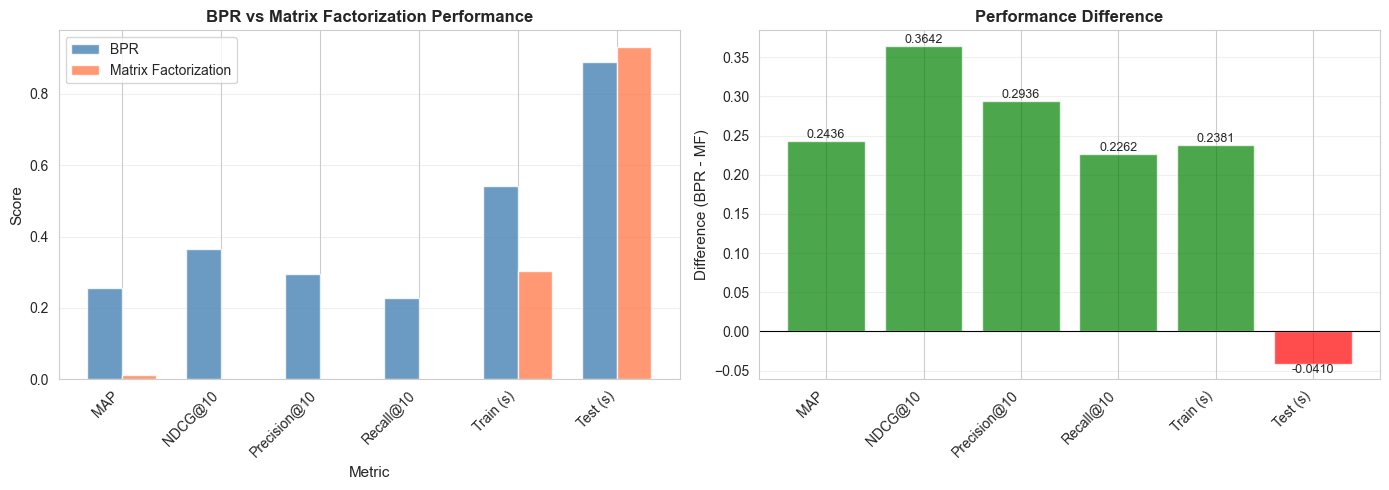


SAMPLE RECOMMENDATIONS FOR USER 0

BPR Top-10 Items:
  1. Item 242 (score: 3.9531)
  2. Item 387 (score: 3.3215)
  3. Item 115 (score: 3.2956)
  4. Item 139 (score: 3.2659)
  5. Item 509 (score: 3.2269)
  6. Item 154 (score: 3.2098)
  7. Item 765 (score: 3.1561)
  8. Item 100 (score: 3.1232)
  9. Item 44 (score: 3.0525)
  10. Item 195 (score: 3.0350)

Matrix Factorization Top-10 Items:
  1. Item 1513 (score: 1.0016)
  2. Item 1536 (score: 1.0006)
  3. Item 1357 (score: 1.0006)
  4. Item 1398 (score: 1.0006)
  5. Item 1177 (score: 1.0005)
  6. Item 1525 (score: 1.0005)
  7. Item 1484 (score: 1.0004)
  8. Item 1339 (score: 1.0004)
  9. Item 1405 (score: 1.0004)
  10. Item 1356 (score: 1.0004)

Overlap in Top-10: 0/10 items (0%)


In [6]:
from cornac.datasets import movielens
from cornac.models import BPR, MF
from cornac.eval_methods import RatioSplit
from cornac.metrics import Recall, Precision, NDCG, MAP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


ratings = movielens.load_feedback(variant='100K')
df = pd.DataFrame(ratings, columns=['user_id', 'item_id', 'rating'])
implicit_feedback = df[df['rating'] >= 3][['user_id', 'item_id']].copy()
implicit_feedback['rating'] = 1.0


eval_method = RatioSplit(implicit_feedback.values, test_size=0.2, seed=123, verbose=False)


print("="*80)
print("TRAINING BEST BPR MODEL")
print("="*80)
bpr = BPR(k=50, learning_rate=0.01, lambda_reg=0.01, max_iter=200, verbose=False)

result_bpr, _ = eval_method.evaluate(
    bpr,
    metrics=[Recall(k=10), Precision(k=10), NDCG(k=10), MAP()],
    user_based=True
)

bpr_metrics = result_bpr.metric_avg_results
print("\nBPR Results:")
for metric, value in bpr_metrics.items():
    print(f"  {metric}: {value:.4f}")

# 2. Matrix Factorization Model
print("\n" + "="*80)
print("TRAINING MATRIX FACTORIZATION MODEL")
print("="*80)

eval_method_mf = RatioSplit(implicit_feedback.values, test_size=0.2, seed=123, verbose=False)

mf = MF(k=50, learning_rate=0.01, lambda_reg=0.01, max_iter=200, verbose=False)

result_mf, _ = eval_method_mf.evaluate(
    mf,
    metrics=[Recall(k=10), Precision(k=10), NDCG(k=10), MAP()],
    user_based=True
)

mf_metrics = result_mf.metric_avg_results
print("\nMatrix Factorization Results:")
for metric, value in mf_metrics.items():
    print(f"  {metric}: {value:.4f}")


print("\n" + "="*80)
print("COMPARISON: BPR vs Matrix Factorization")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': list(bpr_metrics.keys()),
    'BPR': list(bpr_metrics.values()),
    'MF': list(mf_metrics.values()),
})

comparison_df['Difference'] = comparison_df['BPR'] - comparison_df['MF']
comparison_df['Winner'] = comparison_df['Difference'].apply(lambda x: 'BPR' if x > 0 else 'MF')

print("\n" + comparison_df.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_list = [m for m in bpr_metrics.keys()]
bpr_values = [bpr_metrics[m] for m in metrics_list]
mf_values = [mf_metrics[m] for m in metrics_list]

x = np.arange(len(metrics_list))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, bpr_values, width, label='BPR', color='steelblue', alpha=0.8)
ax.bar(x + width/2, mf_values, width, label='Matrix Factorization', color='coral', alpha=0.8)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('BPR vs Matrix Factorization Performance', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

differences = [b - m for b, m in zip(bpr_values, mf_values)]
colors = ['green' if d > 0 else 'red' for d in differences]
ax = axes[1]
ax.bar(metrics_list, differences, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Difference (BPR - MF)', fontsize=11)
ax.set_title('Performance Difference', fontsize=12, fontweight='bold')
ax.set_xticklabels(metrics_list, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, (metric, diff) in enumerate(zip(metrics_list, differences)):
    ax.text(i, diff, f'{diff:.4f}', ha='center', va='bottom' if diff > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('bpr_vs_mf_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SAMPLE RECOMMENDATIONS FOR USER 0")
print("="*80)

user_id = 0

bpr_scores = bpr.score(user_id)
bpr_top_items = np.argsort(-bpr_scores)[:10]
print(f"\nBPR Top-10 Items:")
for i, item_id in enumerate(bpr_top_items, 1):
    print(f"  {i}. Item {item_id} (score: {bpr_scores[item_id]:.4f})")

mf_scores = mf.score(user_id)
mf_top_items = np.argsort(-mf_scores)[:10]
print(f"\nMatrix Factorization Top-10 Items:")
for i, item_id in enumerate(mf_top_items, 1):
    print(f"  {i}. Item {item_id} (score: {mf_scores[item_id]:.4f})")

overlap = len(set(bpr_top_items) & set(mf_top_items))
print(f"\nOverlap in Top-10: {overlap}/10 items ({overlap*10}%)")

## Discussion 

**Test setup** 
I added another MF recommender to compare Implicit-MF with Implicit-BPR and also compare it to the results from the previous exercise. 
In e5 with explicit BiasedMF, we had:   
**Regression Metrics (BiasedMF, Explicit Feedback)**
| Metric | Value |
|--------|-------|
| RMSE | 0.9512 |
| MAE | 0.7399 |

**Ranking Metrics (BiasedMF, Explicit Feedback)**
| Metric | Value |
|--------|-------|
| nDCG@10 | 0.0466 |
| Precision@10 | 0.0584 |
| Recall@10 | 0.0400 |


**Computational Perspective:**
From a computational perspective, there is no significant difference between the recommenders they take roughly the same time. 
**Results-Based Perspective:**
From a results perspective, BPR is **significantly better**. 
The Implicit-MF achieves a precision of ~0.0005 (0.05%), meaning it almost never finds a relevant top 10 recommendation. 
The explicit BiasedMF results from the previous exercise were better by a factor of
~100, but still perform poorly compared to BPR. 
BPR achieves a precision of 0.2960, while the explicit BiasedMF only reaches 0.0584. There is still a factor of roughly 6. 


From a qualitative view, the BPR results are really usable. Finding every 3rd item in the top 10 is a good, practical result and completely usable compared 
to the results from matrix factorization. 

# f

**Reflect on the relationship between learning objectives and evaluation metrics. In
which scenarios is rating prediction preferable, and in which scenarios are ranking-based
approaches more appropriate?** 

### Core Principle 
The learning objective determines what the model optimizes for and evaluation metrics measure how well this goal is achieved. 

A rating prediction assigns a rating to each item (e.g. 4 stars) and optimizes MSE/RMSE. 
Ranking (BPR) optimizes pairwise ranking, meaning the quality of item ordering is measured (Precision, Recall, nDCG).

Models performing well on one objective can perform badly on the other. In general, item ranking is more useful for actual recommender systems. 

### When to Use What 
Rating prediction is preferable when users explicitly rate items and we need to 
estimate user satisfaction. It is not suited for implicit feedback because there is no rating given that can be predicted.
There are workarounds (e.g. setting all positive interactions to 1.0) but this is not optimal.  

Ranking-based approaches are more appropriate for implicit feedback where the absolute score is not relevant. 
They excel at comparing whether $a > b$, allowing the model to find good recommendations by learning item orderings directly. 
On the other hand, they are suboptimal for explicit feedback, because they usually ignore the rating information available, which 
regression based models can leverage. 